# Probe balanced accuracy by loudness decile: every model, every signal, one method

All 24 figures, from one code path, so gpt-oss and Qwen, direction and grid, differ in their input
tables and nothing else. **`EVAL` (cell 1) picks the rows**, and every figure of one run uses the same rows:

| `EVAL` | rows | direction truth | figures under |
|---|---|---|---|
| `"random_eval"` | each line's **random p2 eval slice**, the uniformly drawn eval tokens (gpt-oss 14,391, Qwen 3,120), from `build_random_eval_tables.sh` | **local belief** (what the probes were trained on) | `.../random_eval/` |
| `"heldout"` | every reasoning token of the held-out set (gpt-oss 360 trajectories, Qwen 70), from `join_opposite_signal.sh` | final `agent_action` (the only label the scorer writes) | `.../` (top level) |

For each (model, probe signal), six figures, all six probes (3 selection arms x {lr, mlp}) per figure:

| # | ruler | rows |
|---|---|---|
| 1 | J-Lens loudness of the probe's own signal | every reasoning token |
| 2 | Logit-Lens loudness, own signal | every reasoning token |
| 3 | J-Lens, own signal | signal words and their +-`EXCLUDE_RADIUS` neighbours removed |
| 4 | Logit-Lens, own signal | same exclusion |
| 5 | J-Lens loudness of the **opposite** signal | every reasoning token |
| 6 | Logit-Lens, opposite signal | every reasoning token |

**One statistic.** Count-pooled balanced accuracy (`stats.bal_acc_from_counts`): per bin, pool each
class's true and correct counts over the bin, then average recall over the classes present. A grid
row already carries per-class cell counts (A # G _, padding excluded). A direction row is one
prediction, so it is turned into the same form: one "cell" whose class is its label. Pooled that way,
the direction number is exactly the per-row macro recall the old direction notebooks reported.
Chance is 0.25 for both.

**Same everything else.** Deciles from `stats.qbin`, recut per ruler and per row subset; tokens with no
mass cell are dropped for that ruler (absent is not quiet). 95% intervals come from resampling
**trajectory names** (300 draws, seed 42, the same draws for every decile). One y range for all 24.

**Inputs.** Each opposite ruler is read at its own line's layer: gpt-oss direction
probes (L15) against grid loudness at L14, gpt-oss grid probes (L14) against direction loudness at L15.
Qwen is L27 on both sides.

**Signal words** are matched after byte-level-BPE decoding (`Ġrow` becomes ` row`). Matching the raw token strings
misses almost all of them (0.12% vs 6.19% of gpt-oss tokens for direction). A token is dropped when a signal word is
within +-`EXCLUDE_RADIUS` tokens of it in its own reasoning chain. A held-out table has every reasoning token as a row,
so a row shift computes that; a slice holds a few dozen tokens per chain, so its table carries the flag precomputed
over the whole chain (`{signal}_word_r2`, from `build_slice_per_token_table.py`). Same definition either way.

In [1]:
# 1. config
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from telos_interp.grid_utils import CELL_SYMBOL_TO_ID
from telos_interp.loudness_analysis import provenance, stats
from telos_interp.loudness_analysis.slice_tokens import decode_bpe

EVAL = "random_eval"  # "random_eval" | "heldout" -- see the table above

BASE = Path("/workspace/loudness_probe_performance_analysis")
ROOT = BASE / "random_eval" if EVAL == "random_eval" else BASE
# build_random_eval_tables.sh / join_opposite_signal.sh output, and where each run's decile CSV goes
TABLE_DIR = {
    "random_eval": lambda model, signal: sorted((BASE / "tables/random_eval" / f"{model}_{signal}/stages").glob("4_*"))[-1],
    "heldout": lambda model, signal: BASE / "tables" / f"{model}_{signal}",
}[EVAL]
OUT_TABLES = BASE / "tables" / ("random_eval" if EVAL == "random_eval" else "")
VOCAB = Path("/workspace/repo/interp/data/jlens")

LENSES = ("jlens", "logitlens")
LENS_LABEL = {"jlens": "J-Lens", "logitlens": "Logit-Lens"}
N_DECILES = 10
N_BOOT = 300
SEED = 42
EXCLUDE_RADIUS = 2

# {lens}_{name}_logmass_L{layer} is the column; `name` is what the tree's sidecar called the
# vocabulary. Qwen's direction trees call it by its file stem, so its columns carry that name --
# except in the held-out table, whose columns were renamed to `direction`. loud_col takes both.
# gpt-oss grid layer: wrappers/gptoss_analysis/grid/grid_layer.sh, the one place it is set
GPTOSS_GRID_LAYER = int(re.search(r"GRID_LAYER:-(\d+)", Path("/workspace/repo/interp/wrappers/gptoss_analysis/grid/grid_layer.sh").read_text())[1])
QWEN_DIRECTION = "direction_tokens_full_qwen3-6-35b-a3b"
RUNS = {
    ("gptoss", "direction"): dict(
        model="gpt-oss-20b",
        own=dict(name="direction", layer=15, vocab=VOCAB / "direction_tokens_full.json"),
        opp=dict(signal="grid", name="grid", layer=GPTOSS_GRID_LAYER),
    ),
    ("gptoss", "grid"): dict(
        model="gpt-oss-20b",
        own=dict(name="grid", layer=GPTOSS_GRID_LAYER, vocab=VOCAB / "grid_tokens_pruned.json"),
        opp=dict(signal="direction", name="direction", layer=15),
    ),
    ("qwen", "direction"): dict(
        model="Qwen3.6-35B-A3B",
        own=dict(name="direction", layer=27, vocab=VOCAB / "qwen/direction_tokens_full_qwen3-6-35b-a3b.json"),
        opp=dict(signal="grid", name="grid", layer=27),
    ),
    ("qwen", "grid"): dict(
        model="Qwen3.6-35B-A3B",
        own=dict(name="grid", layer=27, vocab=VOCAB / "qwen/grid_tokens_pruned_qwen3-6-35b-a3b.json"),
        opp=dict(signal="direction", name="direction", layer=27),
    ),
}

ARMS = ["jlens", "logitlens", "random"]
MTYPES = ["lr", "mlp"]
COLOR = dict(zip(ARMS, sns.color_palette("colorblind", len(ARMS)), strict=True))
STYLE = {"lr": "-", "mlp": "--"}
KEY_RE = re.compile(r"_(?P<arm>jlens|logitlens|random)_(?:multiclass_)?l\d+_(?P<mt>lr|mlp)$")
CHANCE = 0.25
sns.set_theme(style="whitegrid", context="notebook")

## 2. Load each table into count form

In [2]:
GRID_CLASSES = [CELL_SYMBOL_TO_ID[s] for s in ("_", "#", "A", "G")]  # padding '+' excluded
ACTION_CLASSES = [0, 1, 2, 3]  # LEFT UP RIGHT DOWN


def loud_col(columns, lens: str, name: str, layer: int) -> str:
    '''The loudness column for (lens, signal, layer), under whichever spelling the table uses.'''
    names = [name] + ([QWEN_DIRECTION] if name == "direction" else [])
    hits = [c for c in (f"{lens}_{n}_logmass_L{layer}" for n in names) if c in columns]
    assert len(hits) == 1, (lens, name, layer, hits)
    return hits[0]


def load(model: str, signal: str) -> tuple[pd.DataFrame, list[str], list[int]]:
    '''The table with n_true_{c} / {probe}_correct_{c} counts, whichever signal it is.'''
    run = RUNS[(model, signal)]
    path = TABLE_DIR(model, signal) / "per_token_scores.csv"
    # keep_default_na=False: a decoded token can literally be "NA".
    df = pd.read_csv(path, keep_default_na=False, na_values=[""], low_memory=False)
    df = df.sort_values(["name", "step", "abs_pos"], kind="stable").reset_index(drop=True)
    classes = GRID_CLASSES if signal == "grid" else ACTION_CLASSES
    pred_keys = [c[: -len("_pred")] for c in df.columns if c.endswith("_pred")]
    if not pred_keys:  # already count form: every grid table, and every slice table
        keys = sorted(c[: -len("_n_correct")] for c in df.columns if c.endswith("_n_correct"))
    else:  # a held-out direction table: one prediction per row, truth = final action
        keys = pred_keys
        label = df["label"].astype(int)
        new = {}
        for c in classes:
            new[f"n_true_{c}"] = (label == c).astype(np.int64)
            for k in keys:
                new[f"{k}_correct_{c}"] = ((df[f"{k}_pred"].astype(int) == label) & (label == c)).astype(np.int64)
        df = pd.concat([df.drop(columns=[c for c in new if c in df.columns]), pd.DataFrame(new)], axis=1)
    assert len(keys) == 6, keys
    count_cols = [f"n_true_{c}" for c in classes] + [f"{k}_correct_{c}" for k in keys for c in classes]
    df[count_cols] = df[count_cols].apply(pd.to_numeric).astype(np.int64)
    for lens in LENSES:
        for name, layer in ((run["own"]["name"], run["own"]["layer"]), (run["opp"]["name"], run["opp"]["layer"])):
            col = loud_col(df.columns, lens, name, layer)
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df, keys, classes


def probe_meta(key: str) -> dict:
    return KEY_RE.search(key).groupdict()

## 3. Signal-word exclusion (byte-level BPE decoded)

In [3]:
def drop_signal_words(df: pd.DataFrame, signal: str, vocab_json: Path, radius: int) -> pd.DataFrame:
    '''Drop every token with a signal word within +-radius tokens of it in its own reasoning chain.'''
    pre = f"{signal}_word_r{radius}"
    if pre in df.columns:  # a slice table: flagged over the whole chain when it was built
        flag, drop = df[f"{signal}_word"].astype(bool), df[pre].astype(bool)
        print(f"    signal words {flag.mean():.2%} of tokens; dropped with radius {radius}: {drop.mean():.2%}")
        return df[~drop]
    vocab = {t for lst in json.loads(vocab_json.read_text()).values() for t in lst}
    uniq = pd.Series(df["token"].unique())
    is_word = dict(zip(uniq, uniq.map(decode_bpe).isin(vocab), strict=True))
    flag = df["token"].map(is_word).astype(bool)
    drop = flag.copy()
    grouped = flag.groupby([df["name"], df["step"]])
    for s in range(1, radius + 1):
        drop |= grouped.shift(s, fill_value=False).astype(bool) | grouped.shift(-s, fill_value=False).astype(bool)
    print(f"    signal words {flag.mean():.2%} of tokens; dropped with radius {radius}: {drop.mean():.2%}")
    return df[~drop]

## 4. Balanced accuracy per decile, trajectory-clustered 95% CI

In [4]:
def decile_table(df: pd.DataFrame, keys, classes, col: str) -> pd.DataFrame:
    d = df[np.isfinite(df[col])].copy()
    d["decile"] = stats.qbin(d[col], N_DECILES, labels=False).astype(int) + 1
    count_cols = [f"n_true_{c}" for c in classes] + [f"{k}_correct_{c}" for k in keys for c in classes]
    agg = d.groupby(["decile", "name"])[count_cols].sum()
    meta = d.groupby("decile").agg(n_tokens=("name", "size"), n_traj=("name", "nunique"), mean_logmass=(col, "mean"))

    names = np.sort(d["name"].unique())
    rng = np.random.default_rng(SEED)
    # One set of trajectory draws for every decile, as a (draw x trajectory) weight matrix.
    weights = np.stack([np.bincount(rng.integers(0, len(names), len(names)), minlength=len(names)) for _ in range(N_BOOT)])

    rows = []
    for dec, g in agg.groupby(level="decile"):
        g = g.droplevel("decile").reindex(names, fill_value=0)
        boot = pd.DataFrame(weights @ g.to_numpy(np.float64), columns=count_cols)
        true_b = boot[[f"n_true_{c}" for c in classes]].to_numpy()
        for k in keys:
            point, _ = stats.bal_acc_from_counts(g, k, classes)
            corr_b = boot[[f"{k}_correct_{c}" for c in classes]].to_numpy()
            with np.errstate(invalid="ignore", divide="ignore"):
                rec_b = np.where(true_b > 0, corr_b / true_b, np.nan)  # (draw x class)
                ba_b = np.nanmean(rec_b, axis=1)
            row = {"decile": int(dec), "probe_key": k, **probe_meta(k), "bal_acc": point,
                   "lo": np.nanpercentile(ba_b, 2.5), "hi": np.nanpercentile(ba_b, 97.5)}
            # Per-class recall from the same pooled counts and the same draws, so the panels in
            # cell 7 are the balanced accuracy's own components, not a second computation.
            for j, c in enumerate(classes):
                n_c = g[f"n_true_{c}"].sum()
                row |= {f"recall_{c}": g[f"{k}_correct_{c}"].sum() / n_c if n_c else np.nan,
                        f"recall_{c}_lo": np.nanpercentile(rec_b[:, j], 2.5) if n_c else np.nan,
                        f"recall_{c}_hi": np.nanpercentile(rec_b[:, j], 97.5) if n_c else np.nan}
            rows.append(row | meta.loc[dec].to_dict())
    return pd.DataFrame(rows)

## 5. The 24 tables

In [5]:
def fig_path(model: str, signal: str, lens: str, ruler: str, excluded: bool) -> Path:
    folder = "same_signal_evals" if ruler == signal else "opposite_signal_evals"
    stem = f"{model}_{signal}-probes_{lens}_{ruler}-loudness"
    if excluded:
        stem += f"_no-{signal}-words-r{EXCLUDE_RADIUS}"
    return ROOT / folder / signal / f"{stem}.png"


PANELS = []  # (path, table, x label)
for (model, signal), run in RUNS.items():
    print(f"{model} / {signal}")
    df, keys, classes = load(model, signal)
    print(f"  {len(df):,} rows, {df['name'].nunique()} trajectories")
    quiet = drop_signal_words(df, signal, run["own"]["vocab"], EXCLUDE_RADIUS)
    specs = []
    for lens in LENSES:
        own = loud_col(df.columns, lens, run["own"]["name"], run["own"]["layer"])
        opp = loud_col(df.columns, lens, run["opp"]["name"], run["opp"]["layer"])
        specs += [(lens, signal, False, df, own), (lens, signal, True, quiet, own), (lens, run["opp"]["signal"], False, df, opp)]
    tables = []
    for lens, ruler, excluded, frame, col in specs:
        tab = decile_table(frame, keys, classes, col).assign(
            model=model, probe_signal=signal, lens=lens, ruler_signal=ruler, ruler_column=col, excluded=excluded
        )
        tables.append(tab)
        PANELS.append((fig_path(model, signal, lens, ruler, excluded), tab, f"{LENS_LABEL[lens]} {ruler} loudness"))
    out = OUT_TABLES / f"{model}_{signal}" / "accuracy_by_loudness_decile.csv"
    pd.concat(tables, ignore_index=True).to_csv(out, index=False)
    print(f"  -> {out}")

assert len(PANELS) == 24

gptoss / direction
  14,391 rows, 720 trajectories
    signal words 6.92% of tokens; dropped with radius 2: 30.13%


  -> /workspace/loudness_probe_performance_analysis/tables/random_eval/gptoss_direction/accuracy_by_loudness_decile.csv
gptoss / grid
  14,391 rows, 720 trajectories
    signal words 7.42% of tokens; dropped with radius 2: 31.85%


  -> /workspace/loudness_probe_performance_analysis/tables/random_eval/gptoss_grid/accuracy_by_loudness_decile.csv
qwen / direction
  3,120 rows, 52 trajectories
    signal words 2.47% of tokens; dropped with radius 2: 10.93%


  -> /workspace/loudness_probe_performance_analysis/tables/random_eval/qwen_direction/accuracy_by_loudness_decile.csv
qwen / grid
  3,120 rows, 52 trajectories
    signal words 10.87% of tokens; dropped with radius 2: 33.56%


  -> /workspace/loudness_probe_performance_analysis/tables/random_eval/qwen_grid/accuracy_by_loudness_decile.csv


## 6. Figures: one y range, one style, no titles

y range: (np.float64(0.1), np.float64(0.9))


-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/direction/gptoss_direction-probes_jlens_direction-loudness.png


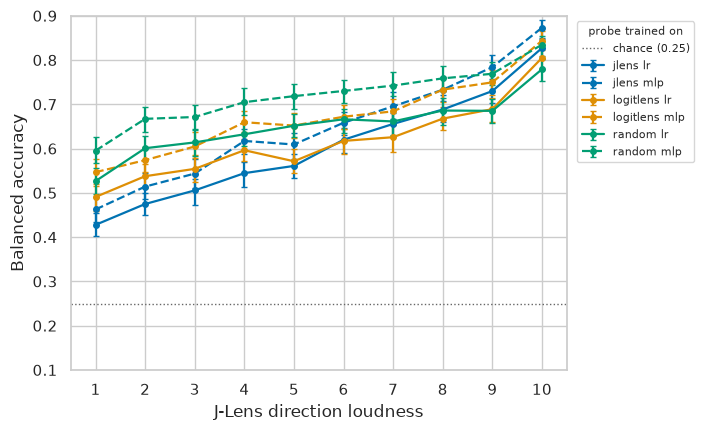

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/direction/gptoss_direction-probes_jlens_direction-loudness_no-direction-words-r2.png


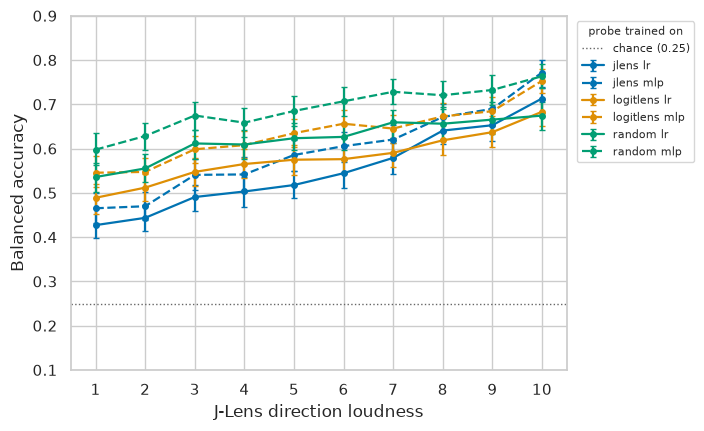

-> /workspace/loudness_probe_performance_analysis/random_eval/opposite_signal_evals/direction/gptoss_direction-probes_jlens_grid-loudness.png


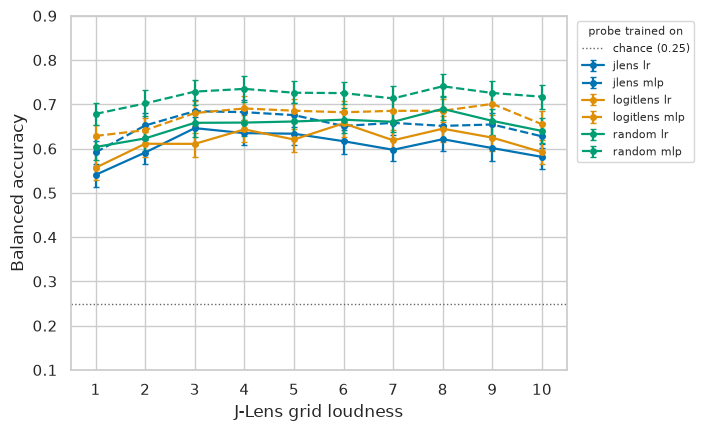

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/direction/gptoss_direction-probes_logitlens_direction-loudness.png


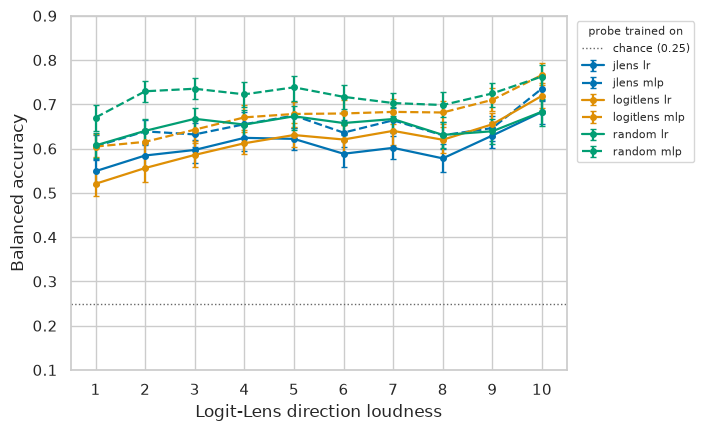

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/direction/gptoss_direction-probes_logitlens_direction-loudness_no-direction-words-r2.png


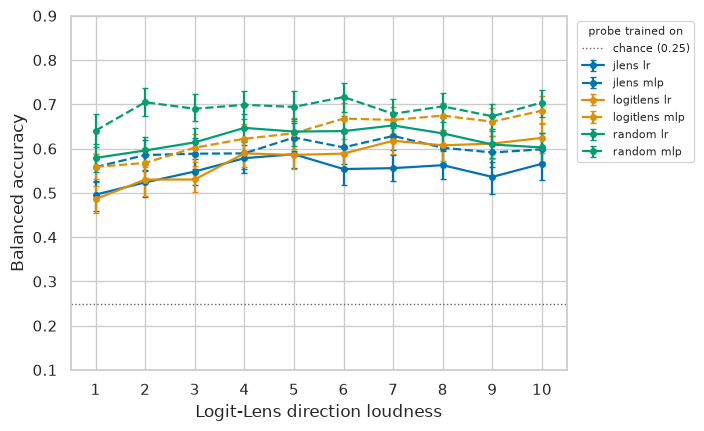

-> /workspace/loudness_probe_performance_analysis/random_eval/opposite_signal_evals/direction/gptoss_direction-probes_logitlens_grid-loudness.png


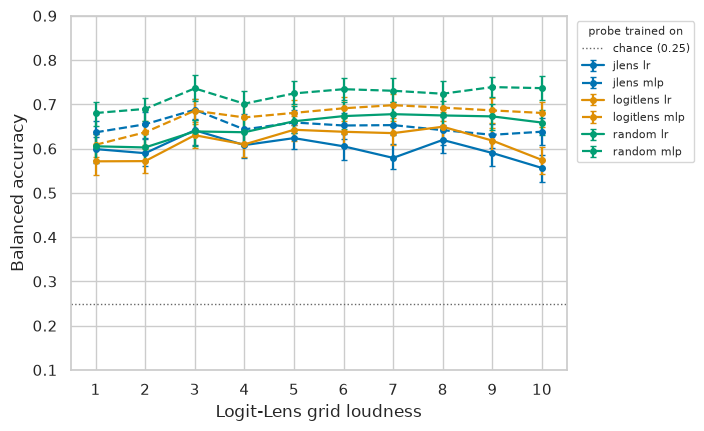

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/grid/gptoss_grid-probes_jlens_grid-loudness.png


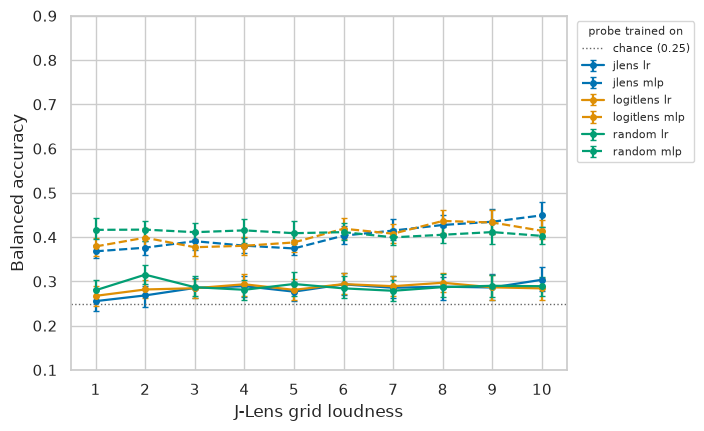

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/grid/gptoss_grid-probes_jlens_grid-loudness_no-grid-words-r2.png


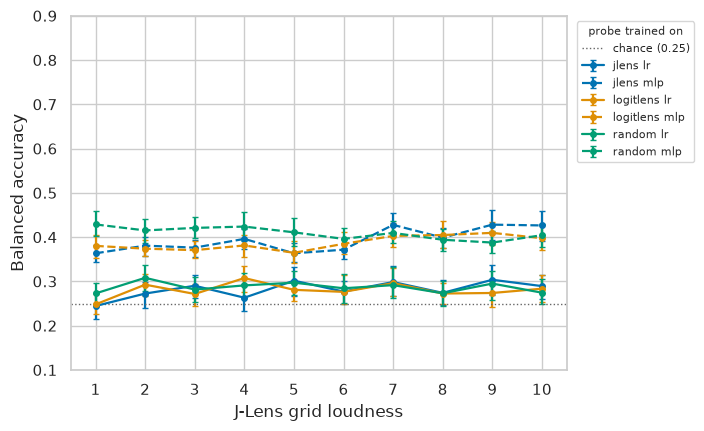

-> /workspace/loudness_probe_performance_analysis/random_eval/opposite_signal_evals/grid/gptoss_grid-probes_jlens_direction-loudness.png


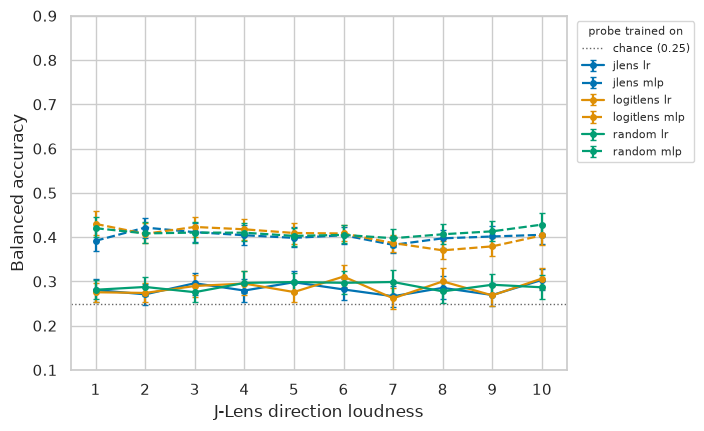

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/grid/gptoss_grid-probes_logitlens_grid-loudness.png


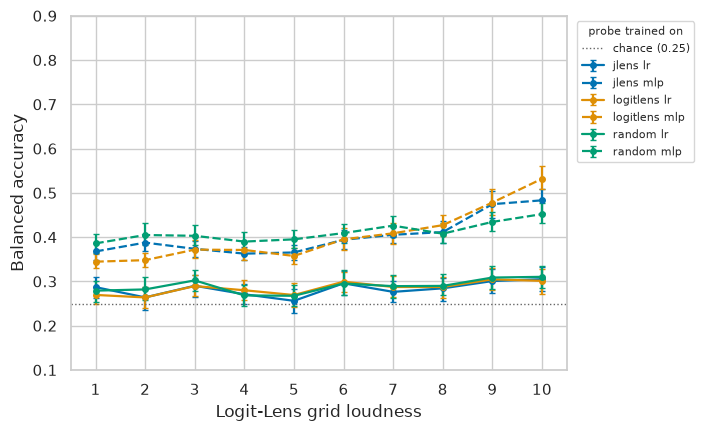

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/grid/gptoss_grid-probes_logitlens_grid-loudness_no-grid-words-r2.png


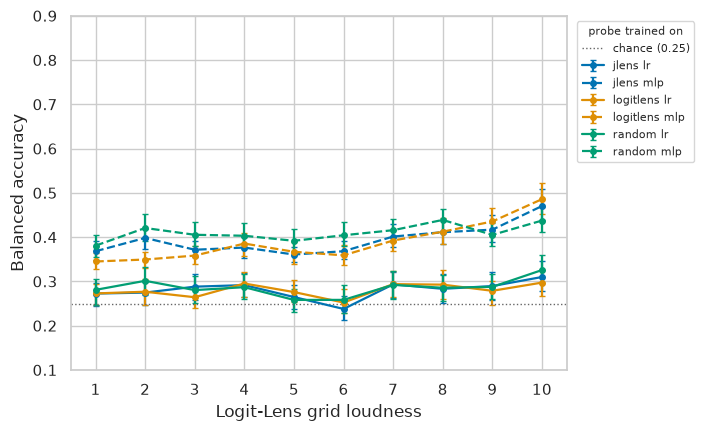

-> /workspace/loudness_probe_performance_analysis/random_eval/opposite_signal_evals/grid/gptoss_grid-probes_logitlens_direction-loudness.png


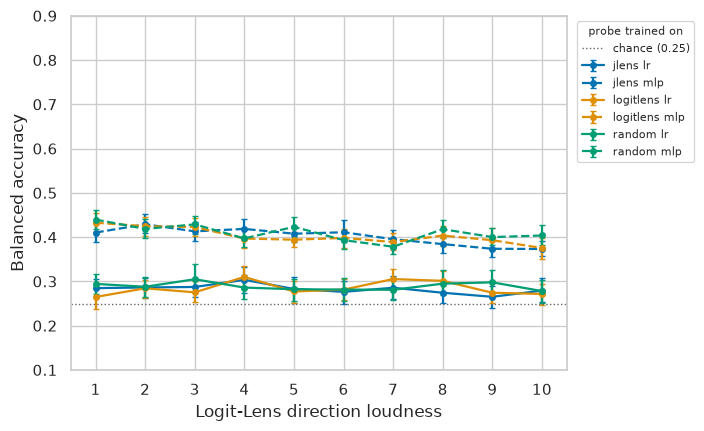

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/direction/qwen_direction-probes_jlens_direction-loudness.png


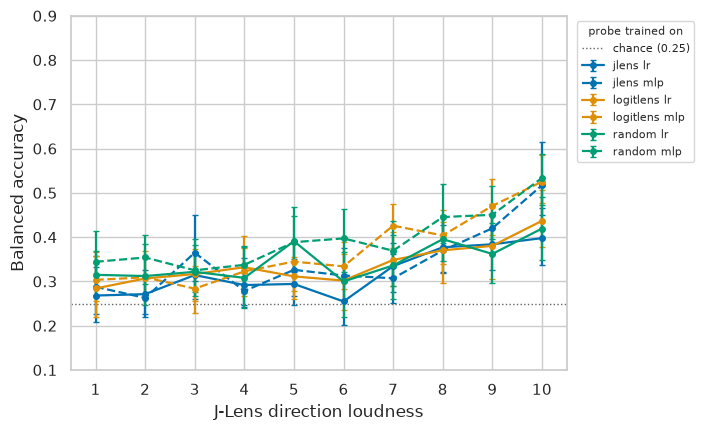

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/direction/qwen_direction-probes_jlens_direction-loudness_no-direction-words-r2.png


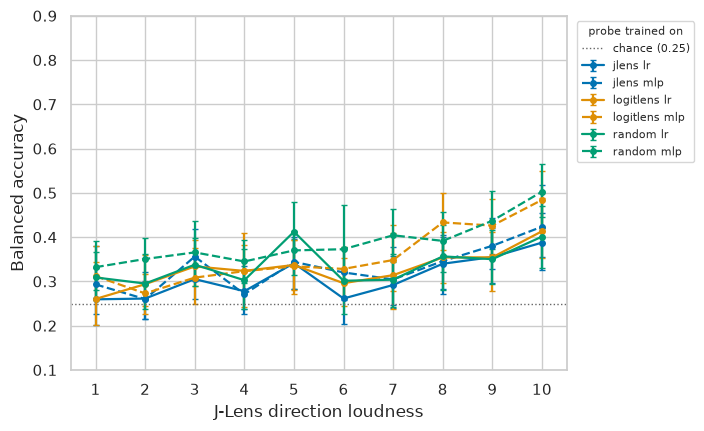

-> /workspace/loudness_probe_performance_analysis/random_eval/opposite_signal_evals/direction/qwen_direction-probes_jlens_grid-loudness.png


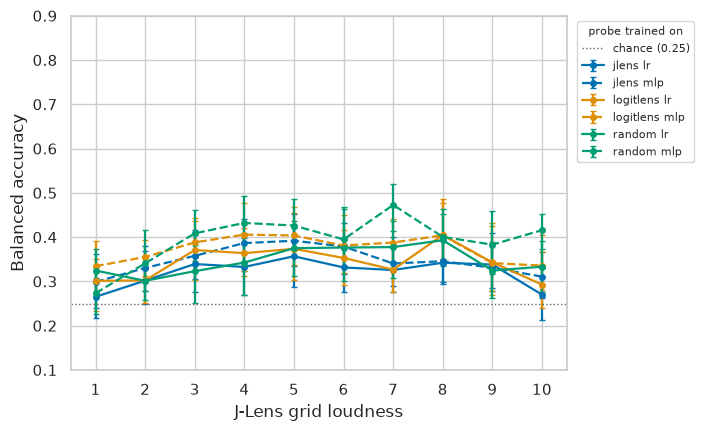

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/direction/qwen_direction-probes_logitlens_direction-loudness.png


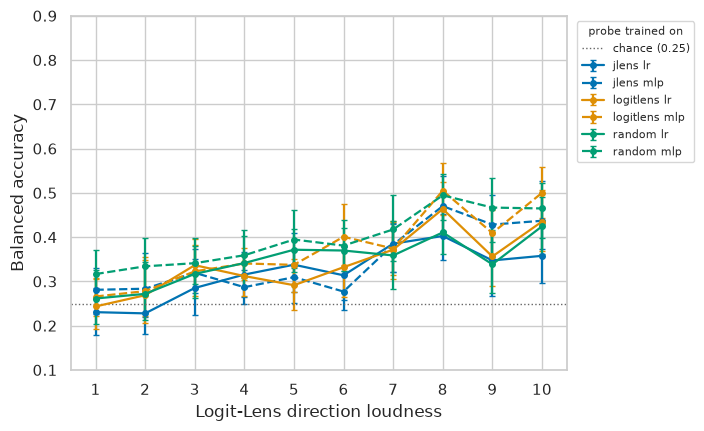

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/direction/qwen_direction-probes_logitlens_direction-loudness_no-direction-words-r2.png


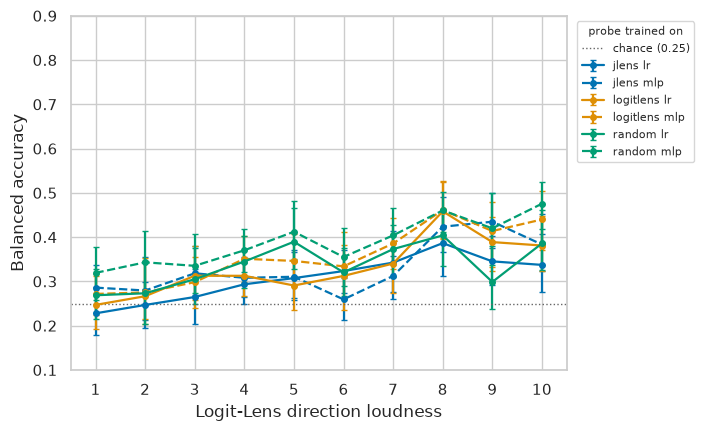

-> /workspace/loudness_probe_performance_analysis/random_eval/opposite_signal_evals/direction/qwen_direction-probes_logitlens_grid-loudness.png


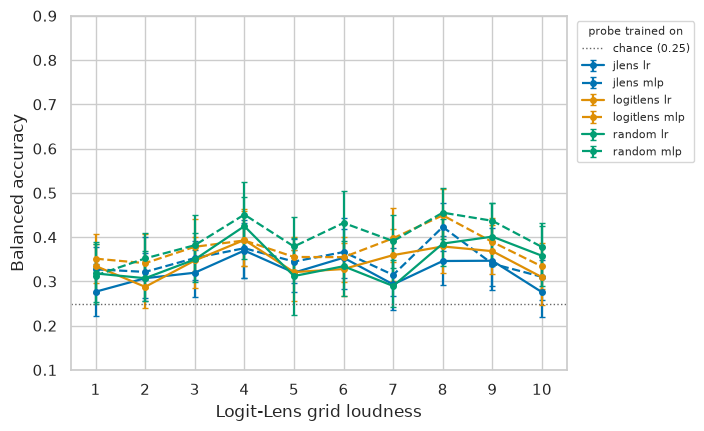

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/grid/qwen_grid-probes_jlens_grid-loudness.png


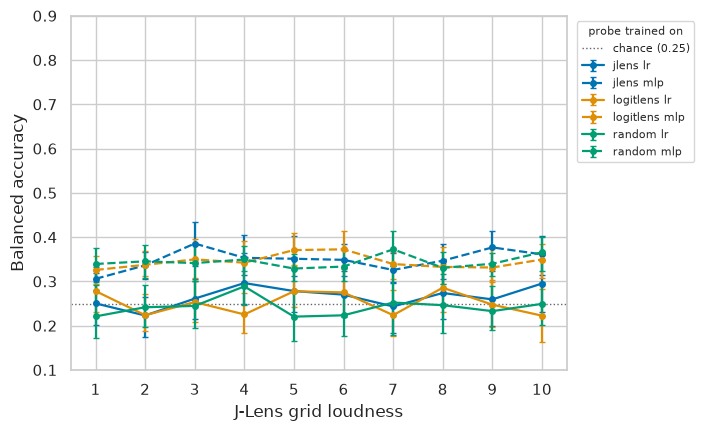

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/grid/qwen_grid-probes_jlens_grid-loudness_no-grid-words-r2.png


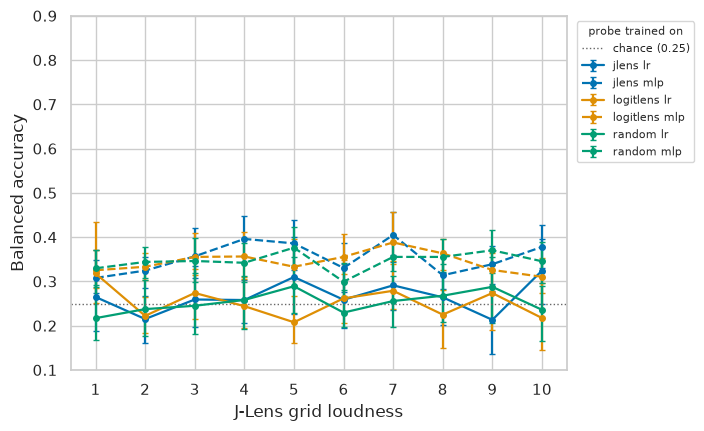

-> /workspace/loudness_probe_performance_analysis/random_eval/opposite_signal_evals/grid/qwen_grid-probes_jlens_direction-loudness.png


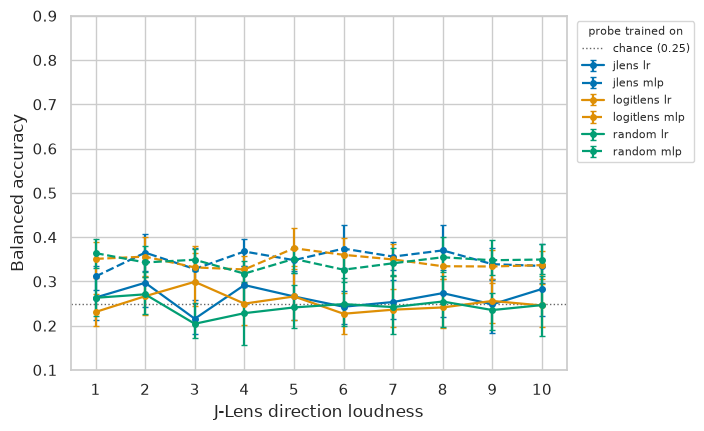

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/grid/qwen_grid-probes_logitlens_grid-loudness.png


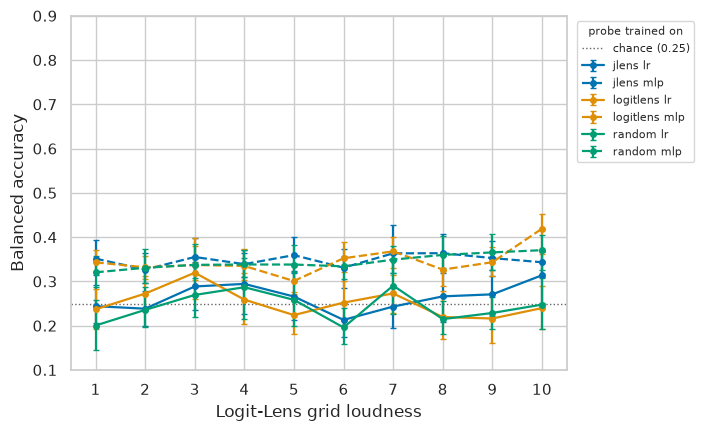

-> /workspace/loudness_probe_performance_analysis/random_eval/same_signal_evals/grid/qwen_grid-probes_logitlens_grid-loudness_no-grid-words-r2.png


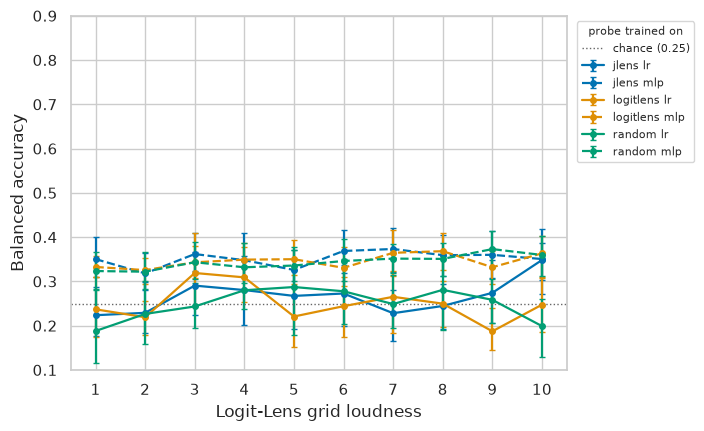

-> /workspace/loudness_probe_performance_analysis/random_eval/opposite_signal_evals/grid/qwen_grid-probes_logitlens_direction-loudness.png


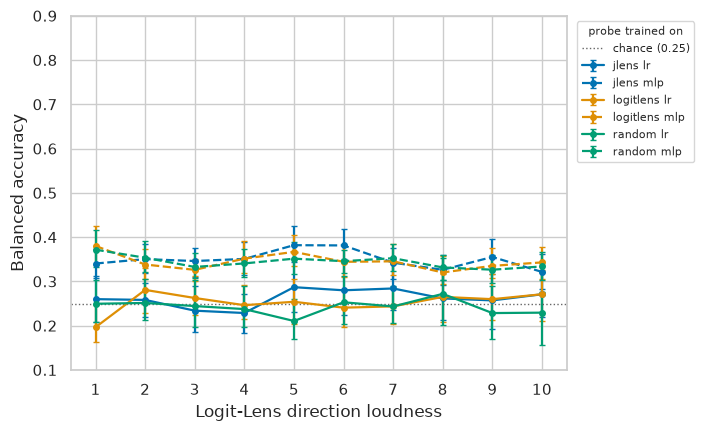

In [6]:
ALL = pd.concat([t for _, t, _ in PANELS])
YLIM = (np.floor(min(ALL.lo.min(), CHANCE) * 20) / 20, np.ceil(ALL.hi.max() * 20) / 20)
print("y range:", YLIM)


def draw(tab: pd.DataFrame, xlabel: str, path: Path) -> None:
    fig, ax = plt.subplots(figsize=(6.4, 4.6))
    for arm in ARMS:
        for mt in MTYPES:
            t = tab[(tab.arm == arm) & (tab.mt == mt)].sort_values("decile")
            err = np.vstack([np.clip(t.bal_acc - t.lo, 0, None), np.clip(t.hi - t.bal_acc, 0, None)])
            ax.errorbar(t.decile, t.bal_acc, yerr=err, marker="o", ms=4, lw=1.6, ls=STYLE[mt],
                        color=COLOR[arm], capsize=2, label=f"{arm} {mt}")
    ax.axhline(CHANCE, ls=":", lw=1, color="0.4", label=f"chance ({CHANCE:.2f})")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Balanced accuracy")
    ax.set_xticks(range(1, N_DECILES + 1))
    ax.set_xlim(0.5, N_DECILES + 0.5)
    ax.set_ylim(*YLIM)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, title="probe trained on", title_fontsize=8)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print(f"-> {path}")
    plt.show()
    plt.close(fig)


for path, tab, xlabel in PANELS:
    draw(tab, xlabel, path)

## 7. Grid probes, one figure per cell class

The 12 grid-probe figures above, each split into its four classes: **recall** of that class, from the same
pooled counts and the same trajectory draws as the balanced accuracy (which is their mean). Same x axes, same
style, one y range across all 48. There is no chance line: a class's recall under a chance-level guesser depends
on how often the probe predicts that class, which the tables do not record. A and G are one cell per grid, so
their recalls rest on few cells per decile and their bands are wide.

Saved under `ROOT / "grid_per_class" / <class>/`, with the same file name as the parent figure.

In [7]:
GRID_CLASS_NAME = {CELL_SYMBOL_TO_ID["_"]: "empty", CELL_SYMBOL_TO_ID["#"]: "wall",
                   CELL_SYMBOL_TO_ID["A"]: "agent", CELL_SYMBOL_TO_ID["G"]: "goal"}
GRID_PANELS = [(p, t, x) for p, t, x in PANELS if t.probe_signal.iloc[0] == "grid"]
assert len(GRID_PANELS) == 12

GT = pd.concat([t for _, t, _ in GRID_PANELS])
lo_all = min(GT[f"recall_{c}_lo"].min() for c in GRID_CLASS_NAME)
hi_all = max(GT[f"recall_{c}_hi"].max() for c in GRID_CLASS_NAME)
YLIM_CLASS = (max(0.0, np.floor(lo_all * 20) / 20), min(1.0, np.ceil(hi_all * 20) / 20))
print("per-class y range:", YLIM_CLASS)


def draw_class(tab: pd.DataFrame, c: int, xlabel: str, path: Path) -> None:
    fig, ax = plt.subplots(figsize=(6.4, 4.6))
    for arm in ARMS:
        for mt in MTYPES:
            t = tab[(tab.arm == arm) & (tab.mt == mt)].sort_values("decile")
            y, lo, hi = t[f"recall_{c}"], t[f"recall_{c}_lo"], t[f"recall_{c}_hi"]
            err = np.vstack([np.clip(y - lo, 0, None).fillna(0), np.clip(hi - y, 0, None).fillna(0)])
            ax.errorbar(t.decile, y, yerr=err, marker="o", ms=4, lw=1.6, ls=STYLE[mt],
                        color=COLOR[arm], capsize=2, label=f"{arm} {mt}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"Recall ({GRID_CLASS_NAME[c]})")
    ax.set_xticks(range(1, N_DECILES + 1))
    ax.set_xlim(0.5, N_DECILES + 0.5)
    ax.set_ylim(*YLIM_CLASS)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, title="probe trained on", title_fontsize=8)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print(f"-> {path}")
    plt.close(fig)  # saved, not shown: 48 inline images would push the notebook past the repo's size cap


CLASS_FIGS = []
for path, tab, xlabel in GRID_PANELS:
    for c, cname in GRID_CLASS_NAME.items():
        out = ROOT / "grid_per_class" / cname / path.name
        draw_class(tab, c, xlabel, out)
        CLASS_FIGS.append(out)
assert len(CLASS_FIGS) == 48

per-class y range: (0.0, np.float64(0.9))


-> /workspace/loudness_probe_performance_analysis/random_eval/grid_per_class/empty/gptoss_grid-probes_jlens_grid-loudness.png


-> /workspace/loudness_probe_performance_analysis/random_eval/grid_per_class/wall/gptoss_grid-probes_jlens_grid-loudness.png


-> /workspace/loudness_probe_performance_analysis/random_eval/grid_per_class/agent/gptoss_grid-probes_jlens_grid-loudness.png
-> /workspace/loudness_probe_performance_analysis/random_eval/grid_per_class/goal/gptoss_grid-probes_jlens_grid-loudness.png


-> /workspace/loudness_probe_performance_analysis/random_eval/grid_per_class/empty/gptoss_grid-probes_jlens_grid-loudness_no-grid-words-r2.png


...

-> /workspace/loudness_probe_performance_analysis/random_eval/grid_per_class/agent/qwen_grid-probes_logitlens_grid-loudness_no-grid-words-r2.png


-> /workspace/loudness_probe_performance_analysis/random_eval/grid_per_class/goal/qwen_grid-probes_logitlens_grid-loudness_no-grid-words-r2.png


-> /workspace/loudness_probe_performance_analysis/random_eval/grid_per_class/empty/qwen_grid-probes_logitlens_direction-loudness.png
-> /workspace/loudness_probe_performance_analysis/random_eval/grid_per_class/wall/qwen_grid-probes_logitlens_direction-loudness.png


-> /workspace/loudness_probe_performance_analysis/random_eval/grid_per_class/agent/qwen_grid-probes_logitlens_direction-loudness.png


-> /workspace/loudness_probe_performance_analysis/random_eval/grid_per_class/goal/qwen_grid-probes_logitlens_direction-loudness.png


## 8. Binary agent probes against agent loudness (gpt-oss, `EVAL = "random_eval"` only)

The two one-vs-rest **agent-cell** probes (`/workspace/probes/grid_binary_l15/grid_binary_probe_agent_{lr,mlp}.pt`:
random arm, layer 15, `A` vs every other cell, padding included) on their own eval split
(`grid_binary_l15_random_split_eval`, 720 trajectories, 25 cells per token), binned by the loudness of the
**agent** vocabulary (`data/jlens/agent_tokens.json`) at L15. Inputs: `build_agent_loudness_eval720.sh` (GPU, the
agent mass tables), then `build_random_eval_tables.sh` with `ONLY=gptoss_agent`.

Four figures, as 1-4 above: J-Lens and Logit-Lens, every token and with agent words +-`EXCLUDE_RADIUS` removed.
One line per probe type; there is one arm only.

**The statistic is the binary one.** `stats.bal_acc_binary_from_counts`: pooled recall of `A` and pooled
specificity over every other cell, averaged, the same number `eval_binary_cognitive_map_probe` reports as
`balanced_accuracy`. Chance is **0.5**, not 0.25, so these figures have their own y range. `A` is ~0.5% of cells,
so recall rests on a few hundred cells per decile; the components figure beside each one (`agent_components/`)
shows recall and specificity separately.

**Vocabulary caveat.** `agent_tokens.json` is the AGENT class copied out of `grid_tokens_full.json` by hand, not
built by a vocabulary notebook, and it holds very common pieces (`a`, ` a`, ` an`, `A`, ` A`). Read the
exclusion figures with that in mind: dropping "agent words" also drops every English article.

In [ ]:
AGENT_TABLE = BASE / "tables/random_eval/gptoss_agent/stages/3_agent/per_token_scores.csv"
AGENT_VOCAB = VOCAB / "agent_tokens.json"
AGENT_LAYER = 15
AGENT_ID = CELL_SYMBOL_TO_ID["A"]
AGENT_CHANCE = 0.5
AGENT_KEY_RE = re.compile(r"grid_binary_probe_agent_(?P<mt>lr|mlp)$")


def load_agent(path: Path) -> tuple[pd.DataFrame, list[str]]:
    '''The agent slice table, with each probe's pooled confusion counts per token.

    The evaluator writes per-class counts (n_true_{c}, {probe}_correct_{c}); a non-agent cell is
    correct when called negative. So TP is the agent class's correct count and TN is the sum
    over every other class, padding included, as the probe was trained and evaluated.
    '''
    df = pd.read_csv(path, keep_default_na=False, na_values=[""], low_memory=False)
    df = df.sort_values(["name", "step", "abs_pos"], kind="stable").reset_index(drop=True)
    classes = [int(c[len("n_true_"):]) for c in df.columns if c.startswith("n_true_")]
    keys = sorted(c[: -len("_n_correct")] for c in df.columns if c.endswith("_n_correct"))
    assert len(keys) == 2 and all(AGENT_KEY_RE.search(k) for k in keys), keys
    assert AGENT_ID in classes, classes
    neg = [c for c in classes if c != AGENT_ID]
    n_neg = df[[f"n_true_{c}" for c in neg]].sum(axis=1)
    new = {}
    for k in keys:
        tp = df[f"{k}_correct_{AGENT_ID}"].astype(np.int64)
        tn = df[[f"{k}_correct_{c}" for c in neg]].sum(axis=1).astype(np.int64)
        new |= {f"{k}_tp": tp, f"{k}_fn": df[f"n_true_{AGENT_ID}"] - tp, f"{k}_tn": tn, f"{k}_fp": n_neg - tn}
    df = pd.concat([df, pd.DataFrame(new)], axis=1)
    for lens in LENSES:
        col = loud_col(df.columns, lens, "agent", AGENT_LAYER)
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df, keys


def decile_table_binary(df: pd.DataFrame, keys, col: str) -> pd.DataFrame:
    '''`decile_table`, for a one-vs-rest probe: same bins, same trajectory draws, binary statistic.'''
    d = df[np.isfinite(df[col])].copy()
    d["decile"] = stats.qbin(d[col], N_DECILES, labels=False).astype(int) + 1
    count_cols = [f"{k}_{s}" for k in keys for s in ("tp", "fn", "tn", "fp")]
    agg = d.groupby(["decile", "name"])[count_cols].sum()
    meta = d.groupby("decile").agg(n_tokens=("name", "size"), n_traj=("name", "nunique"), mean_logmass=(col, "mean"))

    names = np.sort(d["name"].unique())
    rng = np.random.default_rng(SEED)
    weights = np.stack([np.bincount(rng.integers(0, len(names), len(names)), minlength=len(names)) for _ in range(N_BOOT)])

    rows = []
    for dec, g in agg.groupby(level="decile"):
        g = g.droplevel("decile").reindex(names, fill_value=0)
        boot = pd.DataFrame(weights @ g.to_numpy(np.float64), columns=count_cols)
        for k in keys:
            point, recall, spec = stats.bal_acc_binary_from_counts(g, k)
            tp, fn, tn, fp = (boot[f"{k}_{s}"].to_numpy() for s in ("tp", "fn", "tn", "fp"))
            with np.errstate(invalid="ignore", divide="ignore"):
                rec_b = np.where(tp + fn > 0, tp / (tp + fn), np.nan)
                spec_b = np.where(tn + fp > 0, tn / (tn + fp), np.nan)
                ba_b = np.nanmean(np.stack([rec_b, spec_b]), axis=0)
            row = {"decile": int(dec), "probe_key": k, "arm": "random", **AGENT_KEY_RE.search(k).groupdict(),
                   "n_agent_cells": int(g[f"{k}_tp"].sum() + g[f"{k}_fn"].sum())}
            for stat, point_v, b in (("bal_acc", point, ba_b), ("recall", recall, rec_b), ("specificity", spec, spec_b)):
                row |= {stat: point_v, f"{stat}_lo": np.nanpercentile(b, 2.5), f"{stat}_hi": np.nanpercentile(b, 97.5)}
            rows.append(row | meta.loc[dec].to_dict())
    return pd.DataFrame(rows).rename(columns={"bal_acc_lo": "lo", "bal_acc_hi": "hi"})


def draw_agent(tab: pd.DataFrame, stats_: list[str], ylabels: list[str], xlabel: str, path: Path, ylim, show: bool):
    fig, axes = plt.subplots(1, len(stats_), figsize=(6.4 * len(stats_), 4.6), squeeze=False)
    for ax, stat, ylabel in zip(axes[0], stats_, ylabels, strict=True):
        lo, hi = ("lo", "hi") if stat == "bal_acc" else (f"{stat}_lo", f"{stat}_hi")
        for mt in MTYPES:
            t = tab[tab.mt == mt].sort_values("decile")
            err = np.vstack([np.clip(t[stat] - t[lo], 0, None).fillna(0), np.clip(t[hi] - t[stat], 0, None).fillna(0)])
            ax.errorbar(t.decile, t[stat], yerr=err, marker="o", ms=4, lw=1.6, ls=STYLE[mt],
                        color=COLOR["random"], capsize=2, label=f"random {mt}")
        if stat == "bal_acc":
            ax.axhline(AGENT_CHANCE, ls=":", lw=1, color="0.4", label=f"chance ({AGENT_CHANCE:.2f})")
            ax.set_ylim(*ylim)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(1, N_DECILES + 1))
        ax.set_xlim(0.5, N_DECILES + 0.5)
    axes[0, -1].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, title="agent probe", title_fontsize=8)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print(f"-> {path}")
    if show:
        plt.show()
    plt.close(fig)


AGENT_FIGS = []
if EVAL != "random_eval":
    print("agent probes: only the random_eval slice has an agent table; skipped")
elif not AGENT_TABLE.exists():
    print(f"agent probes: {AGENT_TABLE} missing -- run build_agent_loudness_eval720.sh (GPU), "
          "then ONLY=gptoss_agent build_random_eval_tables.sh; skipped")
else:
    adf, akeys = load_agent(AGENT_TABLE)
    print(f"gpt-oss / agent: {len(adf):,} rows, {adf['name'].nunique()} trajectories")
    aquiet = drop_signal_words(adf, "agent", AGENT_VOCAB, EXCLUDE_RADIUS)
    atabs = []
    for lens in LENSES:
        col = loud_col(adf.columns, lens, "agent", AGENT_LAYER)
        for excluded, frame in ((False, adf), (True, aquiet)):
            tab = decile_table_binary(frame, akeys, col).assign(
                model="gptoss", probe_signal="agent", lens=lens, ruler_signal="agent", ruler_column=col, excluded=excluded
            )
            atabs.append((fig_path("gpt-oss-20b", "agent", lens, "agent", excluded), tab, f"{LENS_LABEL[lens]} agent loudness"))
    AT = pd.concat([t for _, t, _ in atabs], ignore_index=True)
    out = OUT_TABLES / "gptoss_agent" / "accuracy_by_loudness_decile.csv"
    out.parent.mkdir(parents=True, exist_ok=True)
    AT.to_csv(out, index=False)
    print(f"  -> {out}")
    AYLIM = (np.floor(min(AT.lo.min(), AGENT_CHANCE) * 20) / 20, np.ceil(AT.hi.max() * 20) / 20)
    print("agent y range:", AYLIM)
    for path, tab, xlabel in atabs:
        draw_agent(tab, ["bal_acc"], ["Balanced accuracy"], xlabel, path, AYLIM, show=True)
        comp = ROOT / "agent_components" / path.name
        draw_agent(tab, ["recall", "specificity"], ["Recall (agent)", "Specificity (not agent)"], xlabel, comp, AYLIM, show=False)
        AGENT_FIGS += [path, comp]

## 9. Provenance

In [8]:
cfg = provenance.RunConfig("wrappers/loudness_analysis/probe_performance_by_loudness.ipynb")
for model, signal in RUNS:
    cfg.input(f"{model}_{signal}", TABLE_DIR(model, signal) / "per_token_scores.csv")
if AGENT_FIGS:
    cfg.input("gptoss_agent", AGENT_TABLE)
cfg.aggregation(
    balanced_accuracy="counts", classes_grid="A # G _ (padding excluded)", classes_direction="LEFT UP RIGHT DOWN",
    eval_rows=EVAL,
    truth_direction="local belief" if EVAL == "random_eval" else "label (final agent_action)", bins=f"stats.qbin, {N_DECILES} quantiles, recut per ruler and subset",
    bootstrap=f"{N_BOOT} draws of trajectory names, seed {SEED}",
    error_bars="95% percentile interval of the trajectory bootstrap (2.5th / 97.5th)", exclude_radius=EXCLUDE_RADIUS,
    ylim=list(map(float, YLIM)),
    agent=dict(probes="grid_binary_l15 agent {lr, mlp}, random arm", balanced_accuracy="binary_counts (recall of A, specificity over the rest incl. padding)",
               vocab=str(AGENT_VOCAB), layer=AGENT_LAYER, chance=AGENT_CHANCE, ran=bool(AGENT_FIGS)),
    layers={f"{m}_{s}": {"own": r["own"]["layer"], "opposite": r["opp"]["layer"]} for (m, s), r in RUNS.items()},
)
cfg.outputs.extend([p for p, _, _ in PANELS] + CLASS_FIGS + AGENT_FIGS)
print("->", cfg.write(ROOT))

-> /workspace/loudness_probe_performance_analysis/random_eval/run_config.json
